<a href="https://colab.research.google.com/github/va23727/CI345_ML/blob/main/CI345_HW2__Diabetes_Prediction_By_Mahamad_Arsh_Vahora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CI345 HW2
# NAME - Mahamad Arsh Vahora
#Date - 5/19/2026

#Step 1 :	Load Data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import drive

drive.mount('/content/drive')

diabetesPrediction = pd.read_csv('/content/drive/MyDrive/CI345_ML/data/diabetes_prediction_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2 : Basic Data Analysis

## Basic Info

In [41]:
# Basic Info
df = diabetesPrediction
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


##Nuber Row & Columns

In [42]:
# Number of Rows and Columns
df.shape

(100000, 9)

##Column Names

In [43]:

names = df.columns

for name in names:
    print(name)

gender
age
hypertension
heart_disease
smoking_history
bmi
HbA1c_level
blood_glucose_level
diabetes


##Data types

In [44]:

df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


##Missing Data

In [45]:

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


##Descriptive Statistics

In [46]:

df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


##Mean, Min, Max, Std of Age and BMI

In [47]:

print(f'Mean of Age: {df["age"].mean():.2f}')
print(f'Mean of BMI: {df["bmi"].mean():.2f}')
print(f'Min of Age: {df["age"].min():.2f}')
print(f'Min of BMI: {df["bmi"].min():.2f}')
print(f'Max of Age: {df["age"].max():.2f}')
print(f'Max of BMI: {df["bmi"].max():.2f}')
print(f'STD of Age: {df["age"].std():.2f}')
print(f'STD of BMI: {df["bmi"].std():.2f}')

Mean of Age: 41.89
Mean of BMI: 27.32
Min of Age: 0.08
Min of BMI: 10.01
Max of Age: 80.00
Max of BMI: 95.69
STD of Age: 22.52
STD of BMI: 6.64


#Step 3 : Data Visualization

##Create Pie chart for Smoke History

Text(0.5, 1.0, 'Pie Chart of Smoke History')

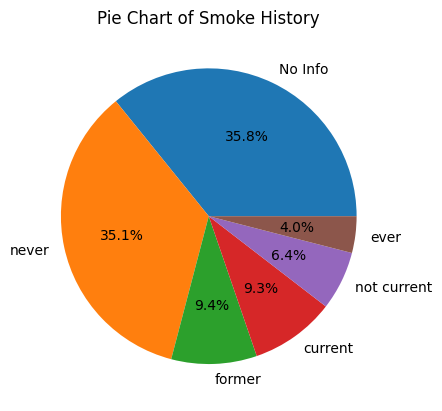

In [48]:
import matplotlib.pyplot as plt

# Pie Chart of Smoke History
smoke_history = df['smoking_history'].value_counts()
plt.pie(smoke_history, labels=smoke_history.index, autopct='%1.1f%%')
plt.title('Pie Chart of Smoke History')

##2)	Bar chart for Smoke History

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64


<Axes: xlabel='smoking_history'>

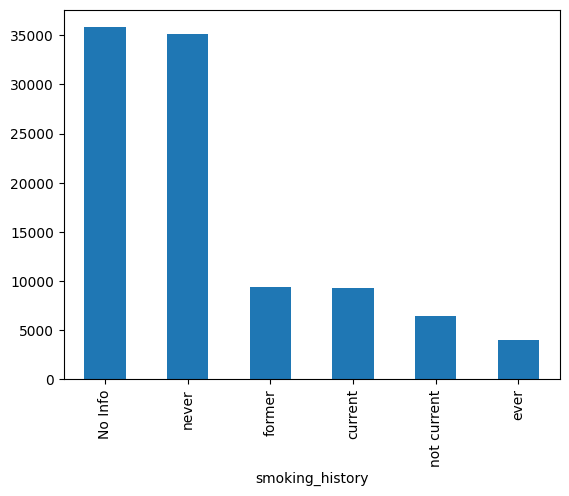

In [49]:
smoke_history = df['smoking_history'].value_counts()
print(smoke_history)
smoke_history.plot(kind='bar')

##Correlation

array([[<Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'HbA1c_level'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'diabetes'}>]], dtype=object)

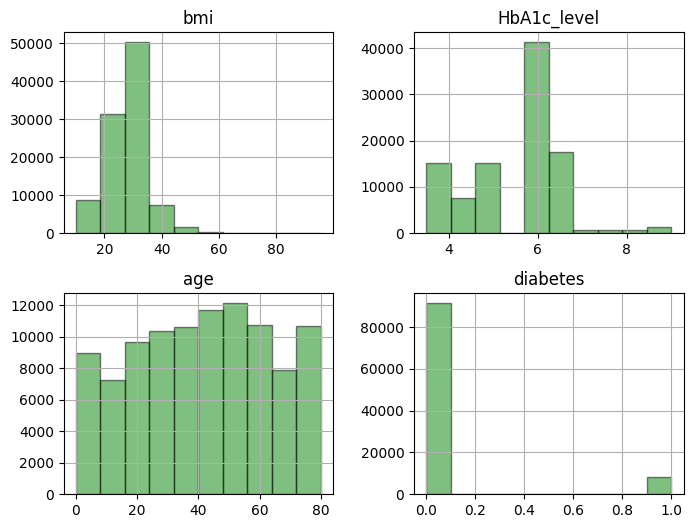

In [50]:
res = df[['bmi', 'HbA1c_level', 'age', 'diabetes']]
res.hist(alpha = 0.5, edgecolor = 'black', color = 'green', figsize = (8, 6))

## Target Data

(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000., 35000.,
        40000.]),
 [Text(0.0, 0, '0'),
  Text(5000.0, 0, '5000'),
  Text(10000.0, 0, '10000'),
  Text(15000.0, 0, '15000'),
  Text(20000.0, 0, '20000'),
  Text(25000.0, 0, '25000'),
  Text(30000.0, 0, '30000'),
  Text(35000.0, 0, '35000'),
  Text(40000.0, 0, '40000')])

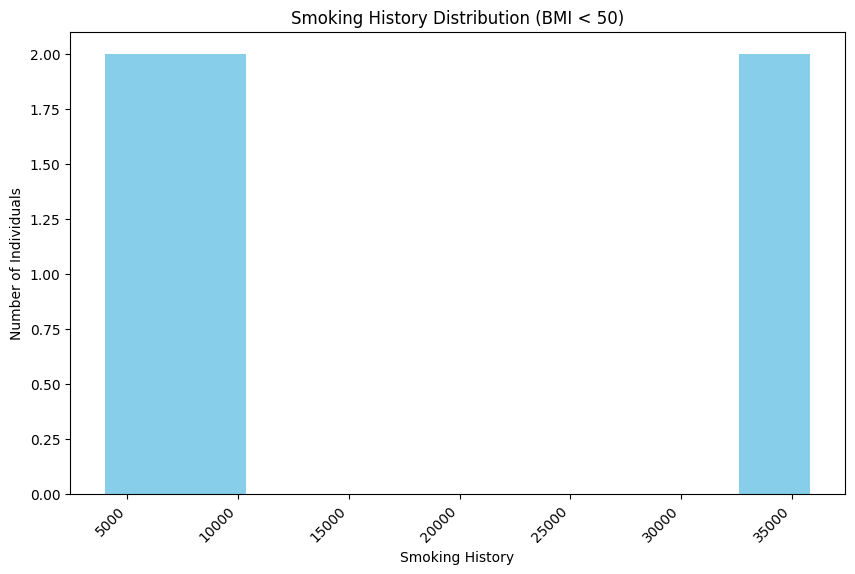

In [51]:
# Filter data where bmi < 50
df_filtered = df[df['bmi'] < 50]

smoking_history_filtered = df_filtered['smoking_history'].value_counts()

plt.figure(figsize=(10, 6))
smoke_history.plot(kind='hist', color='skyblue')
plt.title('Smoking History Distribution (BMI < 50)')
plt.xlabel('Smoking History')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=45, ha='right')

#Step 4 : Data Processing

##Using LabelEncoder for Gender

In [52]:
from sklearn.preprocessing import LabelEncoder
print('--------')



# All category feature need to transfer to numeric feature
encoder = LabelEncoder()
df= df.apply(encoder.fit_transform)


print(df.gender.dtypes)
df.head(2)

--------
int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,101,0,1,4,1334,11,6,0
1,0,75,0,0,0,1547,11,0,0


## Using mapping for Smoking_history

In [53]:
print(df.head(2))
hist_map = {'never':0, 'No Info':2, 'former':1, 'current':10, 'ever':20, 'not current':5}
df['smoking_history'] = df['smoking_history'].map(hist_map)
print(hist_map)
df.head(2)

   gender  age  hypertension  heart_disease  smoking_history   bmi  \
0       0  101             0              1                4  1334   
1       0   75             0              0                0  1547   

   HbA1c_level  blood_glucose_level  diabetes  
0           11                    6         0  
1           11                    0         0  
{'never': 0, 'No Info': 2, 'former': 1, 'current': 10, 'ever': 20, 'not current': 5}


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,101,0,1,NaN,1334,11,6,0
1,0,75,0,0,NaN,1547,11,0,0


##Using dummies

In [54]:
catagory_cols = ['gender', 'smoking_history']

df_use_dummies = pd.get_dummies(df, columns=catagory_cols, dtype = int)
print('----------')
print(df_use_dummies.dtypes)
df_use_dummies.head(2)

----------
age                    int64
hypertension           int64
heart_disease          int64
bmi                    int64
HbA1c_level            int64
blood_glucose_level    int64
diabetes               int64
gender_0               int64
gender_1               int64
gender_2               int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_0,gender_1,gender_2
0,101,0,1,1334,11,6,0,1,0,0
1,75,0,0,1547,11,0,0,1,0,0


##One-hot Encoder

In [55]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['gender']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['gender']))
print(encoded_df.head(2))

   gender_0  gender_1  gender_2
0       1.0       0.0       0.0
1       1.0       0.0       0.0


#Step 5: Separate Data feature and target

In [56]:
print(df.columns)
cols_used = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
df_used = df[cols_used]

target = df['diabetes']

print(df_used.shape)
print(target.shape)
print(target.head(2))
df_used.head(3)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')
(100000, 9)
(100000,)
0    0
1    0
Name: diabetes, dtype: int64


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,101,0,1,NaN,1334,11,6,0
1,0,75,0,0,NaN,1547,11,0,0
2,1,49,0,0,NaN,1547,5,9,0


#Step 6: Training three classifiers

##Using KNN Classifier

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# KNN k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print('===== KNN Classifier (k=3) =====')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

===== KNN Classifier (k=3) =====
Confusion Matrix:
 [[18097   195]
 [  773   935]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     18292
           1       0.83      0.55      0.66      1708

    accuracy                           0.95     20000
   macro avg       0.89      0.77      0.82     20000
weighted avg       0.95      0.95      0.95     20000



In [58]:
# KNN k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print('===== KNN Classifier (k=3) =====')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

===== KNN Classifier (k=3) =====
Confusion Matrix:
 [[18180   112]
 [  801   907]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18292
           1       0.89      0.53      0.67      1708

    accuracy                           0.95     20000
   macro avg       0.92      0.76      0.82     20000
weighted avg       0.95      0.95      0.95     20000



In [59]:
# KNN k=7
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print('===== KNN Classifier (k=3) =====')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

===== KNN Classifier (k=3) =====
Confusion Matrix:
 [[18224    68]
 [  832   876]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.93      0.51      0.66      1708

    accuracy                           0.95     20000
   macro avg       0.94      0.75      0.82     20000
weighted avg       0.95      0.95      0.95     20000



##Using Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

print('\n===== Decision Tree =====')
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


===== Decision Tree =====
Confusion Matrix:
 [[17777   515]
 [  445  1263]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18292
           1       0.71      0.74      0.72      1708

    accuracy                           0.95     20000
   macro avg       0.84      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000



##Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier


# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('===== Random Forest Classifier =====')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

===== Random Forest Classifier =====
Confusion Matrix:
 [[18225    67]
 [  535  1173]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



#Step 7: Finishing following table

In [62]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

results = []

# KNN k=3
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
y_pred_knn3 = knn3.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn3).ravel()
results.append({
    'Classifier': 'KNN (k=3)',
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    'Precision': round(precision_score(y_test, y_pred_knn3), 4),
    'Recall': round(recall_score(y_test, y_pred_knn3), 4),
    'F1-Score': round(f1_score(y_test, y_pred_knn3), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_knn3), 4)
})

# KNN k=5
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
y_pred_knn5 = knn5.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn5).ravel()
results.append({
    'Classifier': 'KNN (k=5)',
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    'Precision': round(precision_score(y_test, y_pred_knn5), 4),
    'Recall': round(recall_score(y_test, y_pred_knn5), 4),
    'F1-Score': round(f1_score(y_test, y_pred_knn5), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_knn5), 4)
})

# KNN k=7
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train, y_train)
y_pred_knn7 = knn7.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_knn7).ravel()
results.append({
    'Classifier': 'KNN (k=7)',
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    'Precision': round(precision_score(y_test, y_pred_knn7), 4),
    'Recall': round(recall_score(y_test, y_pred_knn7), 4),
    'F1-Score': round(f1_score(y_test, y_pred_knn7), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_knn7), 4)
})

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt).ravel()
results.append({
    'Classifier': 'Decision Tree',
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    'Precision': round(precision_score(y_test, y_pred_dt), 4),
    'Recall': round(recall_score(y_test, y_pred_dt), 4),
    'F1-Score': round(f1_score(y_test, y_pred_dt), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_dt), 4)
})

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
results.append({
    'Classifier': 'Random Forest',
    'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    'Precision': round(precision_score(y_test, y_pred_rf), 4),
    'Recall': round(recall_score(y_test, y_pred_rf), 4),
    'F1-Score': round(f1_score(y_test, y_pred_rf), 4),
    'Accuracy': round(accuracy_score(y_test, y_pred_rf), 4)
})

# Display table
df_results = pd.DataFrame(results)
df_results.style.highlight_max(subset=['Precision','Recall','F1-Score','Accuracy'], color='lightgreen') \
                .highlight_min(subset=['FP','FN'], color='lightblue') \
                .set_caption('Classifier Comparison Table')

,Classifier,TP,FP,TN,FN,Precision,Recall,F1-Score,Accuracy
0,KNN (k=3),935,195,18097,773,0.827400,0.547400,0.658900,0.951600
1,KNN (k=5),907,112,18180,801,0.890100,0.531000,0.665200,0.954400
2,KNN (k=7),876,68,18224,832,0.928000,0.512900,0.660600,0.955000
3,Decision Tree,1263,515,17777,445,0.710300,0.739500,0.724600,0.952000
4,Random Forest,1173,67,18225,535,0.946000,0.686800,0.795800,0.969900
